<a href="https://colab.research.google.com/github/hnioua/Introduction-to-Machine-Learning-/blob/main/Atelier_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.draw import circle_perimeter
import numpy as np
from skimage.feature import hog
from skimage import color
import numpy as np
from skimage.feature import hog
from skimage import color
from skimage.feature import canny
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from skimage.feature import hog
from skimage import color, feature
from skimage.feature import canny
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

In [3]:
from tensorflow.keras.datasets import cifar10

# Chargement des données d'entraînement et de test
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalisation comme en PyTorch : de [0, 255] → [-1, 1]
trainset= (x_train / 255.0 - 0.5) / 0.5
testset = (x_test / 255.0 - 0.5) / 0.5


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


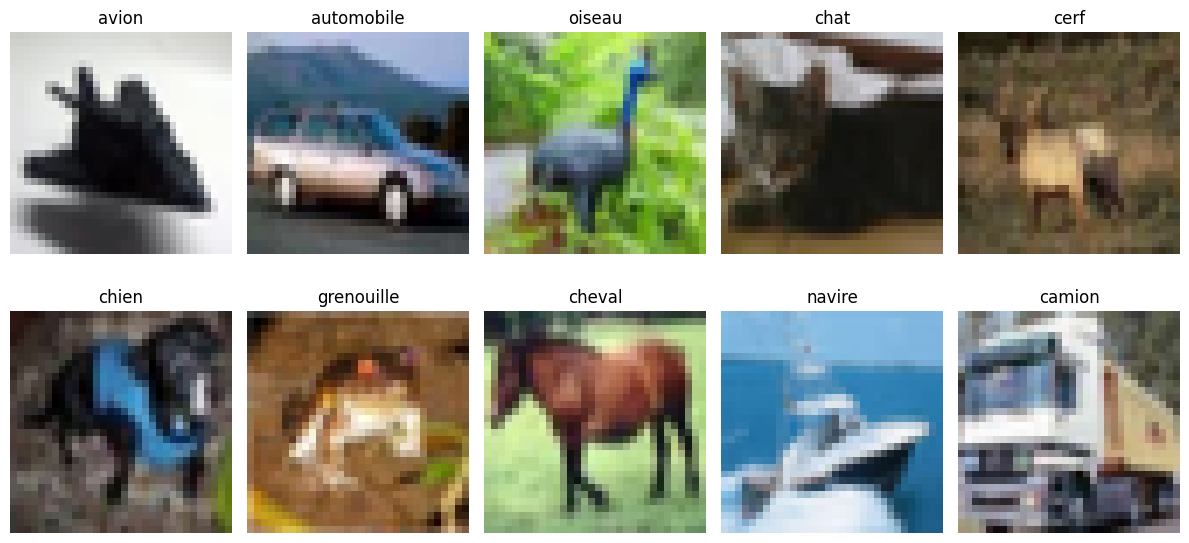

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import cifar10

# Chargement des données
(x_train, y_train), (_, _) = cifar10.load_data()

# Normalisation comme dans PyTorch
x_train_norm = (x_train / 255.0 - 0.5) / 0.5

# Liste des classes
classes = ('avion', 'automobile', 'oiseau', 'chat', 'cerf',
           'chien', 'grenouille', 'cheval', 'navire', 'camion')

# Dictionnaires pour stocker une image par classe
images_per_class = {}
count_per_class = {classname: 0 for classname in classes}

# Collecte d'une seule image par classe
for img, label in zip(x_train_norm, y_train):
    class_index = int(label[0])
    classname = classes[class_index]
    if count_per_class[classname] == 0:
        images_per_class[classname] = img
        count_per_class[classname] += 1
    if len(images_per_class) == 10:
        break

# Affichage
plt.figure(figsize=(12, 6))
for idx, classname in enumerate(classes):
    img = images_per_class[classname]

    # Dénormalisation : x = x * 0.5 + 0.5
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img)
    plt.title(classname)
    plt.axis('off')

plt.tight_layout()
plt.show()


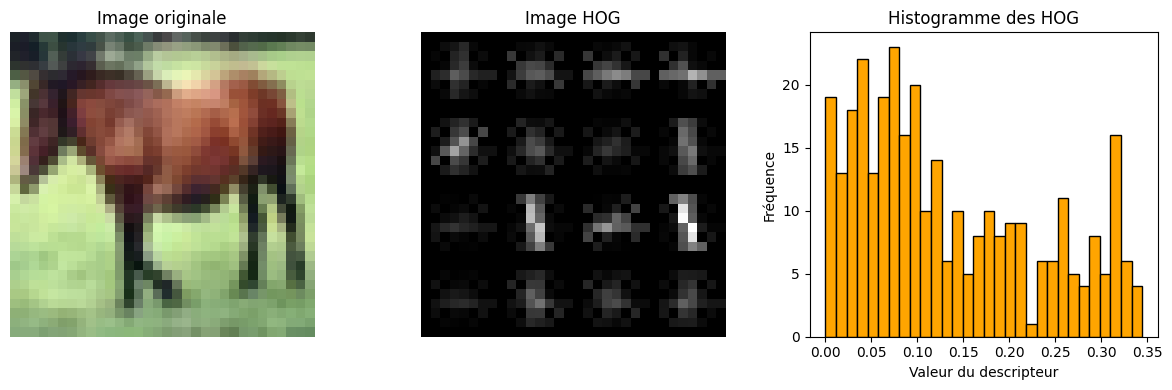

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skimage.feature import hog
from tensorflow.keras.datasets import cifar10

# Rechargement et normalisation des données
# Chargement des données d'entraînement et de test
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train_norm = (x_train / 255.0 - 0.5) / 0.5
x_test_norm = (x_test / 255.0 - 0.5) / 0.5

# Liste des classes
classes = ('avion', 'automobile', 'oiseau', 'chat', 'cerf',
           'chien', 'grenouille', 'cheval', 'navire', 'camion')

# Trouver une image de cheval
images_per_class = {}
for img, label in zip(x_train_norm, y_train):
    class_index = int(label[0])
    classname = classes[class_index]
    if classname == 'cheval':
        images_per_class['cheval'] = img
        break

# Récupérer l'image "cheval" normalisée et la dénormaliser
img = images_per_class['cheval']
npimg = (img * 0.5) + 0.5  # dénormalisation
npimg = np.clip(npimg, 0, 1)

# Conversion en niveaux de gris
gray = color.rgb2gray(npimg)

# Extraction des HOG
fd, hog_image = hog(gray,
                    orientations=9,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=True)

# Affichage
plt.figure(figsize=(12, 4))

# Image originale
plt.subplot(1, 3, 1)
plt.imshow(npimg)
plt.title('Image originale')
plt.axis('off')

# Image HOG
plt.subplot(1, 3, 2)
plt.imshow(hog_image, cmap='gray')
plt.title('Image HOG')
plt.axis('off')

# Histogramme des HOG
plt.subplot(1, 3, 3)
plt.hist(fd, bins=30, color='orange', edgecolor='black')
plt.title('Histogramme des HOG')
plt.xlabel('Valeur du descripteur')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()


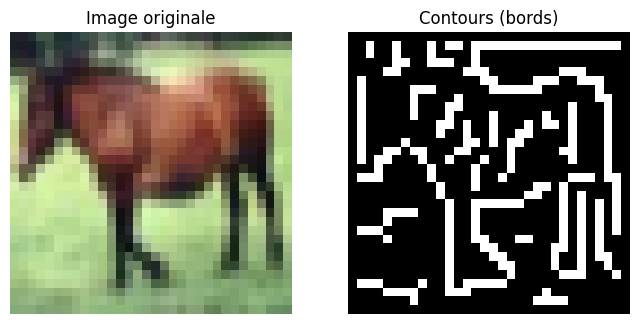

In [6]:
# Convertir en niveau de gris
gray = color.rgb2gray(npimg)

# Détecter les bords (Canny)
edges = canny(gray, sigma=1.0)

# Affichage des bords (approximation visuelle du Shape Context)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(npimg)
plt.title('Image originale')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Contours (bords)')
plt.axis('off')
plt.show()


In [7]:
def extraire_hog_tf(image):
    image = (image * 0.5) + 0.5  # dénormalisation
    gray = color.rgb2gray(image)
    features, _ = hog(gray,
                      orientations=9,
                      pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2),
                      visualize=True)
    return features

In [8]:
def extraire_shape_context_tf(image):
    # Exemple simplifié à remplacer par une vraie extraction de Shape Context
    gray = color.rgb2gray((image * 0.5) + 0.5)
    return gray.flatten()[:128]  # juste pour illustrer

In [9]:
def appliquer_sur_dataset_tf(images, labels, fonction_extraction):
    features = []
    new_labels = []
    for img, lbl in zip(images, labels):
        feat = fonction_extraction(img)
        features.append(feat)
        new_labels.append(int(lbl[0]))
    return np.array(features), np.array(new_labels)


In [10]:
# Données d'entraînement
hog_train, labels_train = appliquer_sur_dataset_tf(trainset, y_train, extraire_hog_tf)
shape_context_train, _ = appliquer_sur_dataset_tf(trainset, y_train, extraire_shape_context_tf)

# Données de test
hog_test, labels_test = appliquer_sur_dataset_tf(testset, y_test, extraire_hog_tf)
shape_context_test, _ = appliquer_sur_dataset_tf(testset, y_test, extraire_shape_context_tf)


In [11]:
shape_context_test

array([[0.45973608, 0.45719843, 0.47735686, ..., 0.41104824, 0.40210392,
        0.37972824],
       [0.92156863, 0.90588235, 0.90980392, ..., 0.92156863, 0.92156863,
        0.92156863],
       [0.72747922, 0.71793176, 0.63639725, ..., 0.89131216, 0.97057686,
        0.95096902],
       ...,
       [0.06214196, 0.05822039, 0.05488706, ..., 0.04732667, 0.05124824,
        0.05545255],
       [0.13644588, 0.11434588, 0.13928118, ..., 0.65926392, 0.64554196,
        0.54721216],
       [0.30086745, 0.40258235, 0.4121149 , ..., 0.31543059, 0.26865451,
        0.25969529]])

In [12]:
print(type(shape_context_test))

<class 'numpy.ndarray'>


In [13]:
hog_train = hog_train.astype(np.float32)
hog_test = hog_test.astype(np.float32)
shape_context_train = shape_context_train.astype(np.float32)
shape_context_test = shape_context_test.astype(np.float32)

In [14]:
import pandas as pd
hog_train = pd.DataFrame(hog_train)
hog_test = pd.DataFrame(hog_test)
hog_train

,0,1,2,3,4,5,6,7,8,9,...,314,315,316,317,318,319,320,321,322,323
0,0.226638,0.176194,0.284600,0.092466,0.191048,0.042175,0.008676,0.034904,0.062335,0.148660,...,0.083328,0.269305,0.269305,0.269305,0.022019,0.236699,0.055783,0.228255,0.075809,0.157570
1,0.181377,0.153786,0.179297,0.251793,0.251793,0.043853,0.026397,0.025709,0.041683,0.143665,...,0.202147,0.254110,0.132265,0.029110,0.254110,0.166502,0.128123,0.120060,0.166881,0.025470
2,0.002027,0.000000,0.006148,0.000147,0.010286,0.000353,0.000000,0.000104,0.000000,0.274871,...,0.000000,0.147618,0.065686,0.038783,0.122391,0.166110,0.018045,0.017799,0.070685,0.035598
3,0.082068,0.116888,0.135197,0.115485,0.238010,0.198063,0.047301,0.036394,0.014401,0.112786,...,0.138056,0.148463,0.129848,0.182459,0.102426,0.254640,0.012364,0.058194,0.040293,0.068767
4,0.040945,0.012214,0.097817,0.148764,0.319796,0.201890,0.039217,0.010265,0.014340,0.021094,...,0.203621,0.012105,0.001720,0.006419,0.076536,0.273247,0.102015,0.008505,0.039697,0.016380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.161455,0.117507,0.252359,0.252359,0.252359,0.118627,0.033971,0.013416,0.081827,0.132722,...,0.003599,0.016277,0.009183,0.010019,0.048094,0.297381,0.278699,0.005406,0.012593,0.013157
49996,0.026555,0.000000,0.007570,0.053096,0.232529,0.279254,0.070561,0.007630,0.008684,0.021396,...,0.063677,0.036984,0.043429,0.043582,0.005882,0.184418,0.189651,0.055291,0.249002,0.133194
49997,0.017270,0.000000,0.000000,0.134409,0.300651,0.041559,0.052672,0.017573,0.000000,0.024984,...,0.079025,0.116570,0.012331,0.000000,0.011148,0.097264,0.068467,0.279748,0.278434,0.124738
49998,0.014042,0.000000,0.001071,0.075934,0.364902,0.082193,0.011431,0.003206,0.000000,0.009092,...,0.114043,0.173457,0.075296,0.245874,0.157201,0.245874,0.061887,0.074277,0.194720,0.164869


In [15]:
hog_test

,0,1,2,3,4,5,6,7,8,9,...,314,315,316,317,318,319,320,321,322,323
0,0.108228,0.079796,0.017791,0.072725,0.114862,0.049443,0.020189,0.108364,0.088764,0.167047,...,0.027843,0.256906,0.256906,0.256906,0.248776,0.237691,0.061986,0.059290,0.012652,0.064857
1,0.013484,0.010303,0.004490,0.010789,0.047499,0.007069,0.008217,0.000000,0.006795,0.035061,...,0.000000,0.232547,0.324200,0.127557,0.041199,0.016325,0.000000,0.000000,0.000000,0.046388
2,0.322079,0.062662,0.030099,0.006730,0.093212,0.046362,0.054563,0.110738,0.322079,0.194871,...,0.033942,0.114208,0.152186,0.172994,0.072459,0.111667,0.010166,0.013892,0.000692,0.021236
3,0.259148,0.207844,0.020435,0.027722,0.096668,0.043353,0.039848,0.098617,0.295525,0.027578,...,0.009012,0.123209,0.000000,0.364045,0.130184,0.364045,0.010521,0.000000,0.000000,0.000000
4,0.150416,0.118484,0.174745,0.118405,0.228632,0.045921,0.060596,0.118614,0.030882,0.266672,...,0.183200,0.233707,0.233707,0.233707,0.194273,0.233707,0.190633,0.087286,0.042703,0.056493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.048735,0.060023,0.152936,0.330526,0.331710,0.232131,0.076809,0.032385,0.115511,0.088697,...,0.077070,0.288441,0.271140,0.288441,0.288441,0.288441,0.012575,0.013094,0.045187,0.069225
9996,0.196813,0.092372,0.157526,0.072381,0.187455,0.030377,0.052309,0.039057,0.003240,0.190273,...,0.214743,0.107991,0.229024,0.257637,0.257637,0.257637,0.008920,0.061256,0.014439,0.047539
9997,0.016874,0.003956,0.021887,0.053265,0.078862,0.048960,0.012407,0.000000,0.000000,0.045984,...,0.075410,0.256054,0.256054,0.018360,0.004964,0.014462,0.038271,0.001335,0.073954,0.110652
9998,0.154377,0.052141,0.141182,0.155861,0.036527,0.013120,0.328754,0.135084,0.047900,0.151520,...,0.200383,0.036390,0.018166,0.018156,0.035213,0.093668,0.036913,0.019541,0.038710,0.009878


In [16]:
shape_context_train = pd.DataFrame(shape_context_train)
shape_context_train

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.240920,0.177609,0.188488,0.220038,0.301170,0.372279,0.437227,0.452057,0.477573,0.487121,...,0.407193,0.384780,0.357046,0.377770,0.376349,0.387831,0.374965,0.362382,0.352872,0.262170
1,0.677778,0.527806,0.406132,0.396346,0.510987,0.645772,0.735753,0.768800,0.600098,0.460261,...,0.364148,0.376478,0.364431,0.307267,0.275046,0.384002,0.348425,0.300257,0.253481,0.280649
2,1.000000,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,...,0.989069,0.990773,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.096298,0.131592,0.135514,0.145306,0.153149,0.143357,0.146445,0.087071,0.101045,0.116954,...,0.339911,0.339911,0.284734,0.258414,0.334033,0.373241,0.337091,0.325288,0.317445,0.286072
4,0.702638,0.694795,0.723913,0.753619,0.762348,0.756774,0.760956,0.755040,0.753595,0.750507,...,0.710028,0.705816,0.702728,0.698806,0.698806,0.687042,0.687875,0.690130,0.683425,0.667739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.627370,0.647811,0.667702,0.671914,0.669682,0.666876,0.685368,0.698531,0.699097,0.699097,...,0.699097,0.683411,0.667724,0.652321,0.644478,0.636635,0.632713,0.631574,0.646978,0.653139
49996,0.937167,0.942511,0.949803,0.954864,0.954864,0.945599,0.927352,0.917537,0.924264,0.933246,...,0.896753,0.878223,0.850444,0.813973,0.755700,0.681488,0.576767,0.443745,0.325064,0.274686
49997,0.594989,0.594676,0.596908,0.605064,0.610638,0.609499,0.615087,0.617870,0.625713,0.628213,...,0.865225,0.873321,0.842774,0.875813,0.933208,0.934845,0.801489,0.628375,0.233152,0.055283
49998,0.817317,0.805270,0.801348,0.800515,0.795760,0.791556,0.787917,0.788200,0.792404,0.788482,...,0.839275,0.827511,0.815478,0.804867,0.792552,0.783057,0.773830,0.759274,0.749765,0.744176


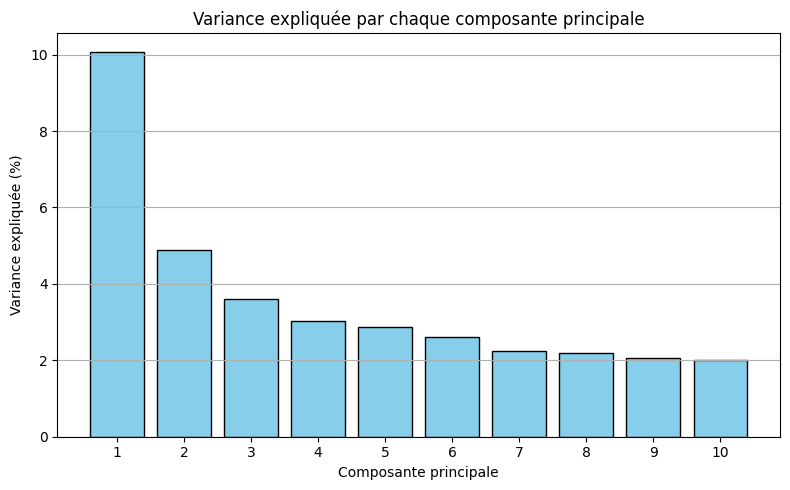

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Appliquer PCA avec plus de composantes pour visualiser la variance
pca_full = PCA(n_components=10)  # Par exemple, 10 composantes
pca_full.fit(hog_train)

# Variance expliquée
explained_var = pca_full.explained_variance_ratio_

# Affichage
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_var) + 1), explained_var * 100, color='skyblue', edgecolor='black')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée (%)')
plt.title("Variance expliquée par chaque composante principale")
plt.grid(axis='y')
plt.xticks(np.arange(1, len(explained_var) + 1))
plt.tight_layout()
plt.show()


In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score

# 1. Création et entraînement du modèle AFD
lda = LinearDiscriminantAnalysis()
lda.fit(hog_train, y_train.flatten())

# 2. Prédictions sur les données de test
y_pred = lda.predict(hog_test)

# 3. Évaluation
print("Précision globale :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_pred, target_names=classes))


Précision globale : 0.5098

Rapport de classification :
               precision    recall  f1-score   support

       avion       0.59      0.55      0.57      1000
  automobile       0.59      0.61      0.60      1000
      oiseau       0.44      0.40      0.42      1000
        chat       0.40      0.32      0.36      1000
        cerf       0.41      0.48      0.45      1000
       chien       0.42      0.41      0.42      1000
  grenouille       0.49      0.60      0.54      1000
      cheval       0.57      0.56      0.56      1000
      navire       0.57      0.56      0.57      1000
      camion       0.61      0.61      0.61      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

#Entraînement avec la stratégie traditionnelle



#1. HOG Features




# Arbre de décision

In [20]:
dt_hog = DecisionTreeClassifier()
dt_hog.fit(hog_train, y_train)  # Use y_train for labels
y_pred_dt_hog = dt_hog.predict(hog_test)
accuracy_dt_hog = accuracy_score(y_test, y_pred_dt_hog)  # Use y_test for true labels

In [43]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Amélioration avec validation croisée pour une évaluation plus fiable
def evaluate_model_with_cross_validation(model, X, y, cv=5):
    """
    Évalue le modèle avec validation croisée et retourne les scores d'accuracy.
    """
    start_time = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    end_time = time.time()

    print(f"Scores de validation croisée: {scores}")
    print(f"Accuracy moyenne: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    return scores

# 2. Fonction pour tester sur un grand ensemble de données efficacement
def test_on_large_dataset(model, X_test, y_test, batch_size=1000):
    """
    Teste le modèle sur un grand ensemble de données par lots pour économiser la mémoire.
    """
    n_samples = X_test.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))
    y_pred = np.zeros(n_samples)

    print(f"Test sur {n_samples} observations en {n_batches} lots")
    start_time = time.time()

    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)

        X_batch = X_test[start_idx:end_idx]
        y_pred[start_idx:end_idx] = model.predict(X_batch)

        if (i + 1) % 10 == 0 or (i + 1) == n_batches:
            print(f"Traitement du lot {i+1}/{n_batches}")

    end_time = time.time()
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy sur l'ensemble de test: {accuracy:.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    # Afficher le rapport de classification détaillé
    print("\nRapport de classification:")
    print(classification_report(y_test, y_pred))

    # Afficher la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédictions')
    plt.ylabel('Valeurs réelles')
    plt.title('Matrice de confusion')
    plt.show()

    return y_pred, accuracy

# 3. Fonction pour créer des attributs supplémentaires à partir des HOG
def enhance_features(X_hog):
    """
    Ajoute des attributs supplémentaires aux caractéristiques HOG existantes.
    """
    n_samples = X_hog.shape[0]

    # 3.1 Ajouter des statistiques sur les caractéristiques HOG
    hog_mean = np.mean(X_hog, axis=1).reshape(-1, 1)
    hog_std = np.std(X_hog, axis=1).reshape(-1, 1)
    hog_max = np.max(X_hog, axis=1).reshape(-1, 1)
    hog_min = np.min(X_hog, axis=1).reshape(-1, 1)

    # 3.2 Ajouter des ratios entre différentes parties des caractéristiques HOG
    n_features = X_hog.shape[1]
    mid_point = n_features // 2

    upper_mean = np.mean(X_hog[:, :mid_point], axis=1).reshape(-1, 1)
    lower_mean = np.mean(X_hog[:, mid_point:], axis=1).reshape(-1, 1)
    ratio = np.divide(upper_mean, lower_mean + 1e-10).reshape(-1, 1)  # Éviter division par zéro

    # 3.3 Calculer des caractéristiques d'asymétrie
    left_third = np.mean(X_hog[:, :n_features//3], axis=1).reshape(-1, 1)
    middle_third = np.mean(X_hog[:, n_features//3:2*n_features//3], axis=1).reshape(-1, 1)
    right_third = np.mean(X_hog[:, 2*n_features//3:], axis=1).reshape(-1, 1)

    # Combiner toutes les nouvelles caractéristiques avec les originales
    X_enhanced = np.hstack((
        X_hog,
        hog_mean, hog_std, hog_max, hog_min,
        upper_mean, lower_mean, ratio,
        left_third, middle_third, right_third
    ))

    print(f"Caractéristiques originales: {X_hog.shape[1]}")
    print(f"Caractéristiques améliorées: {X_enhanced.shape[1]}")

    return X_enhanced

# 4. Recherche des meilleurs hyperparamètres
def optimize_decision_tree(X_train, y_train, cv=5):
    """
    Trouve les meilleurs hyperparamètres pour l'arbre de décision.
    """
    param_grid = {
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }

    dt = DecisionTreeClassifier(random_state=42)
    grid_search = GridSearchCV(dt, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

    print("Début de la recherche des hyperparamètres...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()

    print(f"Meilleurs paramètres: {grid_search.best_params_}")
    print(f"Meilleur score: {grid_search.best_score_:.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    return grid_search.best_estimator_

# 5. Pipeline complet pour l'amélioration du modèle
def build_improved_model(X_train, y_train, use_pca=True, use_smote=True):
    """
    Construit un pipeline complet avec PCA, SMOTE et optimisation.
    """
    steps = []

    # Réduction de dimension avec PCA si demandé
    if use_pca:
        steps.append(('pca', PCA(n_components=0.95)))  # Garde 95% de la variance

    # Modèle final
    steps.append(('classifier', DecisionTreeClassifier(random_state=42)))

    pipeline = Pipeline(steps)

    # Préparation des données avec SMOTE si demandé
    if use_smote:
        print("Application de SMOTE pour équilibrer les classes...")
        smote = SMOTE(random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        X_train, y_train = X_train_resampled, y_train_resampled
        print(f"Nouvelles dimensions après SMOTE: {X_train.shape}")

    # Optimisation des hyperparamètres
    param_grid = {
        'classifier__max_depth': [None, 20, 50],
        'classifier__min_samples_split': [2, 10],
        'classifier__criterion': ['gini', 'entropy']
    }

    if use_pca:
        param_grid['pca__n_components'] = [0.9, 0.95, 0.99]

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    print("Début de l'optimisation du pipeline...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()

    print(f"Meilleurs paramètres: {grid_search.best_params_}")
    print(f"Meilleur score: {grid_search.best_score_:.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    return grid_search.best_estimator_

# 6. Comparer plusieurs modèles
def compare_models(X_train, y_train, X_test, y_test):
    """
    Compare plusieurs modèles sur les mêmes données.
    """
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
    }

    results = {}

    for name, model in models.items():
        print(f"\nÉvaluation de {name}...")

        # Entraînement et prédiction
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        start_time = time.time()
        y_pred = model.predict(X_test)
        predict_time = time.time() - start_time

        # Métriques
        accuracy = accuracy_score(y_test, y_pred)

        results[name] = {
            'accuracy': accuracy,
            'train_time': train_time,
            'predict_time': predict_time
        }

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Temps d'entraînement: {train_time:.2f} secondes")
        print(f"Temps de prédiction: {predict_time:.2f} secondes")

    # Visualisation des résultats
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    accuracies = [results[m]['accuracy'] for m in models]
    plt.bar(models.keys(), accuracies)
    plt.title('Accuracy par modèle')
    plt.ylim(0, 1)

    plt.subplot(1, 2, 2)
    train_times = [results[m]['train_time'] for m in models]
    predict_times = [results[m]['predict_time'] for m in models]

    x = np.arange(len(models))
    width = 0.35

    plt.bar(x - width/2, train_times, width, label='Temps d\'entraînement')
    plt.bar(x + width/2, predict_times, width, label='Temps de prédiction')
    plt.xticks(x, models.keys())
    plt.title('Temps d\'exécution')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return results

# Exemple d'utilisation complet:
# (Décommentez et adaptez selon vos besoins)

'''
# 1. Améliorer les caractéristiques
X_train_enhanced = enhance_features(hog_train)
X_test_enhanced = enhance_features(hog_test)

# 2. Construire et évaluer le modèle amélioré
improved_model = build_improved_model(X_train_enhanced, y_train)

# 3. Tester le modèle sur l'ensemble de test
y_pred, accuracy = test_on_large_dataset(improved_model, X_test_enhanced, y_test)

# 4. Comparer avec d'autres modèles
results = compare_models(X_train_enhanced, y_train, X_test_enhanced, y_test)
'''

"\n# 1. Améliorer les caractéristiques\nX_train_enhanced = enhance_features(hog_train)\nX_test_enhanced = enhance_features(hog_test)\n\n# 2. Construire et évaluer le modèle amélioré\nimproved_model = build_improved_model(X_train_enhanced, y_train)\n\n# 3. Tester le modèle sur l'ensemble de test\ny_pred, accuracy = test_on_large_dataset(improved_model, X_test_enhanced, y_test)\n\n# 4. Comparer avec d'autres modèles\nresults = compare_models(X_train_enhanced, y_train, X_test_enhanced, y_test)\n"

In [45]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Amélioration avec validation croisée pour une évaluation plus fiable
def evaluate_model_with_cross_validation(model, X, y, cv=5):
    """
    Évalue le modèle avec validation croisée et retourne les scores d'accuracy.
    """
    start_time = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    end_time = time.time()

    print(f"Scores de validation croisée: {scores}")
    print(f"Accuracy moyenne: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    return scores

# 2. Fonction pour tester sur un grand ensemble de données efficacement
def test_on_large_dataset(model, X_test, y_test, batch_size=1000):
    """
    Teste le modèle sur un grand ensemble de données par lots pour économiser la mémoire.
    """
    n_samples = X_test.shape[0]
    n_batches = int(np.ceil(n_samples / batch_size))
    y_pred = np.zeros(n_samples)

    print(f"Test sur {n_samples} observations en {n_batches} lots")
    start_time = time.time()

    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)

        X_batch = X_test[start_idx:end_idx]
        y_pred[start_idx:end_idx] = model.predict(X_batch)

        if (i + 1) % 10 == 0 or (i + 1) == n_batches:
            print(f"Traitement du lot {i+1}/{n_batches}")

    end_time = time.time()
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy sur l'ensemble de test: {accuracy:.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    # Afficher le rapport de classification détaillé
    print("\nRapport de classification:")
    print(classification_report(y_test, y_pred))

    # Afficher la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédictions')
    plt.ylabel('Valeurs réelles')
    plt.title('Matrice de confusion')
    plt.show()

    return y_pred, accuracy

# 3. Fonction pour créer des attributs supplémentaires à partir des HOG
def enhance_features(X_hog):
    """
    Ajoute des attributs supplémentaires aux caractéristiques HOG existantes.
    Compatible avec pandas Series/DataFrame et numpy arrays.
    """
    import pandas as pd

    # Convertir en numpy array si c'est un DataFrame ou Series pandas
    is_pandas = False
    if isinstance(X_hog, (pd.DataFrame, pd.Series)):
        is_pandas = True
        # Si c'est une Series, la convertir d'abord en DataFrame
        if isinstance(X_hog, pd.Series):
            X_hog = pd.DataFrame(X_hog)

        # Sauvegarder l'index pour le restaurer plus tard
        original_index = X_hog.index
        X_hog = X_hog.to_numpy()

    n_samples = X_hog.shape[0]

    # Vérifier si X_hog est à 1 dimension (une seule observation)
    if len(X_hog.shape) == 1:
        X_hog = X_hog.reshape(1, -1)

    n_features = X_hog.shape[1]

    # 3.1 Ajouter des statistiques sur les caractéristiques HOG
    hog_mean = np.mean(X_hog, axis=1).reshape(-1, 1)
    hog_std = np.std(X_hog, axis=1).reshape(-1, 1)
    hog_max = np.max(X_hog, axis=1).reshape(-1, 1)
    hog_min = np.min(X_hog, axis=1).reshape(-1, 1)

    # 3.2 Ajouter des ratios entre différentes parties des caractéristiques HOG
    mid_point = n_features // 2

    upper_mean = np.mean(X_hog[:, :mid_point], axis=1).reshape(-1, 1)
    lower_mean = np.mean(X_hog[:, mid_point:], axis=1).reshape(-1, 1)
    ratio = np.divide(upper_mean, lower_mean + 1e-10).reshape(-1, 1)  # Éviter division par zéro

    # 3.3 Calculer des caractéristiques d'asymétrie
    left_third = np.mean(X_hog[:, :n_features//3], axis=1).reshape(-1, 1)
    middle_third = np.mean(X_hog[:, n_features//3:2*n_features//3], axis=1).reshape(-1, 1)
    right_third = np.mean(X_hog[:, 2*n_features//3:], axis=1).reshape(-1, 1)

    # Combiner toutes les nouvelles caractéristiques avec les originales
    X_enhanced = np.hstack((
        X_hog,
        hog_mean, hog_std, hog_max, hog_min,
        upper_mean, lower_mean, ratio,
        left_third, middle_third, right_third
    ))

    # Reconvertir en DataFrame si l'entrée était un DataFrame ou Series
    if is_pandas:
        # Créer des noms pour les nouvelles colonnes
        original_cols = [f"feature_{i}" for i in range(n_features)] if not hasattr(X_hog, 'columns') else X_hog.columns.tolist()
        new_cols = original_cols + [
            'hog_mean', 'hog_std', 'hog_max', 'hog_min',
            'upper_mean', 'lower_mean', 'ratio',
            'left_third', 'middle_third', 'right_third'
        ]
        X_enhanced = pd.DataFrame(X_enhanced, index=original_index, columns=new_cols)

    print(f"Caractéristiques originales: {n_features}")
    print(f"Caractéristiques améliorées: {X_enhanced.shape[1]}")

    return X_enhanced

# 4. Recherche des meilleurs hyperparamètres
def optimize_decision_tree(X_train, y_train, cv=5):
    """
    Trouve les meilleurs hyperparamètres pour l'arbre de décision.
    """
    param_grid = {
        'max_depth': [None, 10, 20, 30, 40, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }

    dt = DecisionTreeClassifier(random_state=42)
    grid_search = GridSearchCV(dt, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

    print("Début de la recherche des hyperparamètres...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()

    print(f"Meilleurs paramètres: {grid_search.best_params_}")
    print(f"Meilleur score: {grid_search.best_score_:.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    return grid_search.best_estimator_

# 5. Pipeline complet pour l'amélioration du modèle
def build_improved_model(X_train, y_train, use_pca=True, use_smote=True):
    """
    Construit un pipeline complet avec PCA, SMOTE et optimisation.
    """
    steps = []

    # Réduction de dimension avec PCA si demandé
    if use_pca:
        steps.append(('pca', PCA(n_components=0.95)))  # Garde 95% de la variance

    # Modèle final
    steps.append(('classifier', DecisionTreeClassifier(random_state=42)))

    pipeline = Pipeline(steps)

    # Préparation des données avec SMOTE si demandé
    if use_smote:
        print("Application de SMOTE pour équilibrer les classes...")
        smote = SMOTE(random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        X_train, y_train = X_train_resampled, y_train_resampled
        print(f"Nouvelles dimensions après SMOTE: {X_train.shape}")

    # Optimisation des hyperparamètres
    param_grid = {
        'classifier__max_depth': [None, 20, 50],
        'classifier__min_samples_split': [2, 10],
        'classifier__criterion': ['gini', 'entropy']
    }

    if use_pca:
        param_grid['pca__n_components'] = [0.9, 0.95, 0.99]

    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    print("Début de l'optimisation du pipeline...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()

    print(f"Meilleurs paramètres: {grid_search.best_params_}")
    print(f"Meilleur score: {grid_search.best_score_:.4f}")
    print(f"Temps d'exécution: {end_time - start_time:.2f} secondes")

    return grid_search.best_estimator_

# 6. Comparer plusieurs modèles
def compare_models(X_train, y_train, X_test, y_test):
    """
    Compare plusieurs modèles sur les mêmes données.
    """
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
    }

    results = {}

    for name, model in models.items():
        print(f"\nÉvaluation de {name}...")

        # Entraînement et prédiction
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        start_time = time.time()
        y_pred = model.predict(X_test)
        predict_time = time.time() - start_time

        # Métriques
        accuracy = accuracy_score(y_test, y_pred)

        results[name] = {
            'accuracy': accuracy,
            'train_time': train_time,
            'predict_time': predict_time
        }

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Temps d'entraînement: {train_time:.2f} secondes")
        print(f"Temps de prédiction: {predict_time:.2f} secondes")

    # Visualisation des résultats
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    accuracies = [results[m]['accuracy'] for m in models]
    plt.bar(models.keys(), accuracies)
    plt.title('Accuracy par modèle')
    plt.ylim(0, 1)

    plt.subplot(1, 2, 2)
    train_times = [results[m]['train_time'] for m in models]
    predict_times = [results[m]['predict_time'] for m in models]

    x = np.arange(len(models))
    width = 0.35

    plt.bar(x - width/2, train_times, width, label='Temps d\'entraînement')
    plt.bar(x + width/2, predict_times, width, label='Temps de prédiction')
    plt.xticks(x, models.keys())
    plt.title('Temps d\'exécution')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return results

# Exemple d'utilisation complet:
# (Décommentez et adaptez selon vos besoins)

'''
# 1. Améliorer les caractéristiques
X_train_enhanced = enhance_features(hog_train)
X_test_enhanced = enhance_features(hog_test)

# 2. Construire et évaluer le modèle amélioré
improved_model = build_improved_model(X_train_enhanced, y_train)

# 3. Tester le modèle sur l'ensemble de test
y_pred, accuracy = test_on_large_dataset(improved_model, X_test_enhanced, y_test)

# 4. Comparer avec d'autres modèles
results = compare_models(X_train_enhanced, y_train, X_test_enhanced, y_test)
'''

"\n# 1. Améliorer les caractéristiques\nX_train_enhanced = enhance_features(hog_train)\nX_test_enhanced = enhance_features(hog_test)\n\n# 2. Construire et évaluer le modèle amélioré\nimproved_model = build_improved_model(X_train_enhanced, y_train)\n\n# 3. Tester le modèle sur l'ensemble de test\ny_pred, accuracy = test_on_large_dataset(improved_model, X_test_enhanced, y_test)\n\n# 4. Comparer avec d'autres modèles\nresults = compare_models(X_train_enhanced, y_train, X_test_enhanced, y_test)\n"

In [ ]:
# Exemple d'utilisation du code amélioré
# Supposons que vous avez déjà:
# - hog_train, hog_test: vos caractéristiques HOG
# - y_train, y_test: vos étiquettes

# Importations nécessaires
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Assurez-vous que vos données sont au bon format
def prepare_data(hog_data, labels=None):
    """
    Prépare les données pour l'entraînement/test en s'assurant qu'elles sont dans le bon format.
    """
    # Si hog_data est une Series pandas, la convertir en DataFrame
    if isinstance(hog_data, pd.Series):
        if hog_data.name is None:
            # Si la Series n'a pas de nom, on crée un DataFrame avec une colonne nommée 'feature'
            hog_data = pd.DataFrame(hog_data).reset_index(drop=True)
        else:
            # Sinon, on utilise le nom de la Series comme nom de colonne
            hog_data = pd.DataFrame(hog_data)

    # Si hog_data est un ndarray, le convertir en DataFrame
    elif isinstance(hog_data, np.ndarray):
        if len(hog_data.shape) == 1:
            # Si c'est un tableau 1D, on le transforme en colonne
            hog_data = pd.DataFrame(hog_data.reshape(-1, 1), columns=['feature'])
        else:
            # Sinon, on crée un DataFrame avec des noms de colonnes génériques
            hog_data = pd.DataFrame(hog_data, columns=[f'feature_{i}' for i in range(hog_data.shape[1])])

    # Convertir les labels si nécessaire
    if labels is not None:
        if isinstance(labels, pd.Series):
            labels = labels.values
        elif isinstance(labels, list):
            labels = np.array(labels)

    return hog_data, labels

# Étape 0: Préparation des données
print("Préparation des données...")
hog_train, y_train = prepare_data(hog_train, y_train)
hog_test, y_test = prepare_data(hog_test, y_test)

# Étape 1: Création du modèle de base (ce que vous aviez déjà)
print("Évaluation du modèle de base:")
dt_hog = DecisionTreeClassifier()
dt_hog.fit(hog_train, y_train)
y_pred_dt_hog = dt_hog.predict(hog_test)
accuracy_dt_hog = accuracy_score(y_test, y_pred_dt_hog)
print(f"Accuracy du modèle de base: {accuracy_dt_hog:.4f}")

# Étape 2: Amélioration des caractéristiques
print("\nCréation de caractéristiques améliorées...")
X_train_enhanced = enhance_features(hog_train)
X_test_enhanced = enhance_features(hog_test)

# Étape 3: Évaluation avec validation croisée
print("\nÉvaluation avec validation croisée:")
basic_dt = DecisionTreeClassifier(random_state=42)
scores = evaluate_model_with_cross_validation(basic_dt, X_train_enhanced, y_train, cv=5)

# Étape 4: Optimisation des hyperparamètres
print("\nOptimisation des hyperparamètres:")
best_dt = optimize_decision_tree(X_train_enhanced, y_train)

# Étape 5: Test sur l'ensemble de test complet
print("\nTest du modèle optimisé sur l'ensemble de test:")
y_pred_optimized, accuracy_optimized = test_on_large_dataset(best_dt, X_test_enhanced, y_test)

# Étape 6: Pipeline complet avec PCA et SMOTE
print("\nConstruction du pipeline complet avec PCA et SMOTE:")
full_pipeline = build_improved_model(X_train_enhanced, y_train, use_pca=True, use_smote=True)

# Étape 7: Test du pipeline complet
print("\nTest du pipeline complet:")
y_pred_pipeline, accuracy_pipeline = test_on_large_dataset(full_pipeline, X_test_enhanced, y_test)

# Étape 8: Comparaison avec d'autres modèles
print("\nComparaison de différents modèles:")
comparison_results = compare_models(X_train_enhanced, y_train, X_test_enhanced, y_test)

# Affichage des résultats finaux
print("\n=== RÉSUMÉ DES PERFORMANCES ===")
print(f"Modèle de base: {accuracy_dt_hog:.4f}")
print(f"Modèle avec hyperparamètres optimisés: {accuracy_optimized:.4f}")
print(f"Pipeline complet (PCA + SMOTE): {accuracy_pipeline:.4f}")

Préparation des données...
Évaluation du modèle de base:
Accuracy du modèle de base: 0.2743

Création de caractéristiques améliorées...
Caractéristiques originales: 324
Caractéristiques améliorées: 334
Caractéristiques originales: 324
Caractéristiques améliorées: 334

Évaluation avec validation croisée:
Scores de validation croisée: [0.2644 0.2663 0.2703 0.2747 0.2761]
Accuracy moyenne: 0.2704 ± 0.0046
Temps d'exécution: 130.76 secondes

Optimisation des hyperparamètres:
Début de la recherche des hyperparamètres...


# Forêts aléatoires

In [21]:
rf_hog = RandomForestClassifier()
rf_hog.fit(hog_train, y_train)
y_pred_rf_hog = rf_hog.predict(hog_test)
accuracy_rf_hog = accuracy_score(y_test, y_pred_rf_hog)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# 2. Shape Context Features

# Arbre de décision

In [22]:
dt_shape = DecisionTreeClassifier()
dt_shape.fit(shape_context_train, y_train)
y_pred_dt_shape = dt_shape.predict(shape_context_test)
accuracy_dt_shape = accuracy_score(y_test, y_pred_dt_shape)

# Forêts aléatoires

In [23]:
rf_shape = RandomForestClassifier()
rf_shape.fit(shape_context_train, y_train)
y_pred_rf_shape = rf_shape.predict(shape_context_test)
accuracy_rf_shape = accuracy_score(y_test, y_pred_rf_shape)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# Entraînement avec la validation croisée

# 1. HOG Features


# Arbre de décision

In [24]:
dt_hog_cv = DecisionTreeClassifier()
scores_dt_hog = cross_val_score(dt_hog_cv, hog_train, y_train, cv=5)  # Utiliser hog_train et trainset.targets
mean_accuracy_dt_hog_cv = scores_dt_hog.mean()

# Forêts aléatoires

In [25]:
rf_hog_cv = RandomForestClassifier()
scores_rf_hog = cross_val_score(rf_hog_cv, hog_train, y_train, cv=5)
mean_accuracy_rf_hog_cv = scores_rf_hog.mean()

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

# 2. Shape Context Features

# Arbre de décision

In [26]:
dt_shape_cv = DecisionTreeClassifier()
scores_dt_shape = cross_val_score(dt_shape_cv, shape_context_train, y_train, cv=10)
mean_accuracy_dt_shape_cv = scores_dt_shape.mean()

# Forêts aléatoires

In [27]:
rf_shape_cv = RandomForestClassifier()
scores_rf_shape = cross_val_score(rf_shape_cv, shape_context_train, y_train, cv=5)
mean_accuracy_rf_shape_cv = scores_rf_shape.mean()

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

# --- Matrice de confusion pour la stratégie traditionnelle ---

# 1. HOG Features (Arbre de décision)

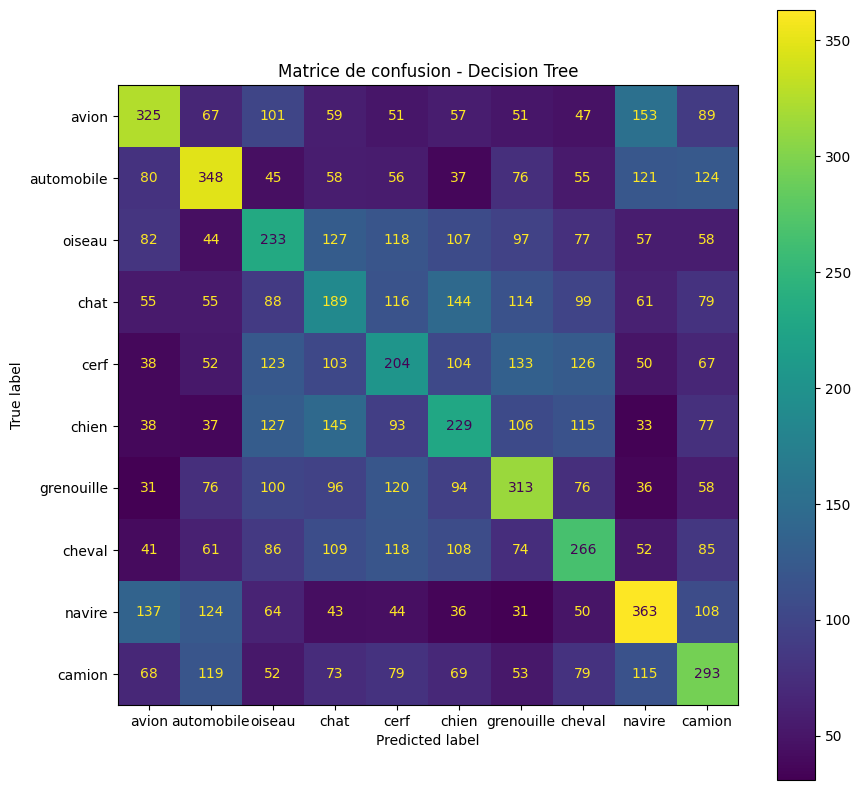

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming 'classes' is a list containing the names of your labels
classes = ('avion', 'automobile', 'oiseau', 'chat', 'cerf',
           'chien', 'grenouille', 'cheval', 'navire', 'camion')

# Matrice de confusion pour Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_hog)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=classes)

# Augmenter la taille de la figure
fig, ax = plt.subplots(figsize=(10, 10)) # Adjust the figsize as needed

disp_dt.plot(ax=ax) # Pass the ax to the plot function
plt.title('Matrice de confusion - Decision Tree')
plt.show()

# 2. HOG Features (Forêts aléatoires)

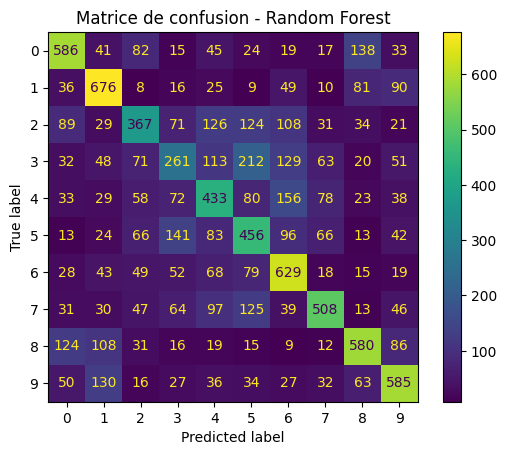

In [29]:
# Matrice de confusion pour Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_hog)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title('Matrice de confusion - Random Forest')
plt.show()

# 3. Shape Context Features (Arbre de décision)


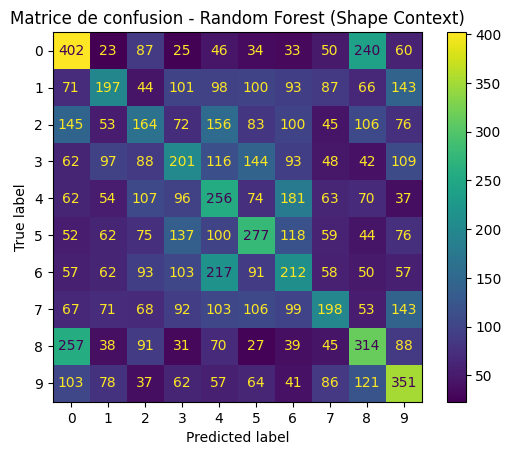

In [30]:

# Matrice de confusion pour Random Forest (shape context)
cm_rf_shape = confusion_matrix(y_test, y_pred_rf_shape)
disp_rf_shape = ConfusionMatrixDisplay(confusion_matrix=cm_rf_shape)
disp_rf_shape.plot()
plt.title('Matrice de confusion - Random Forest (Shape Context)')
plt.show()



# 4. Shape Context Features (Forêts aléatoires)

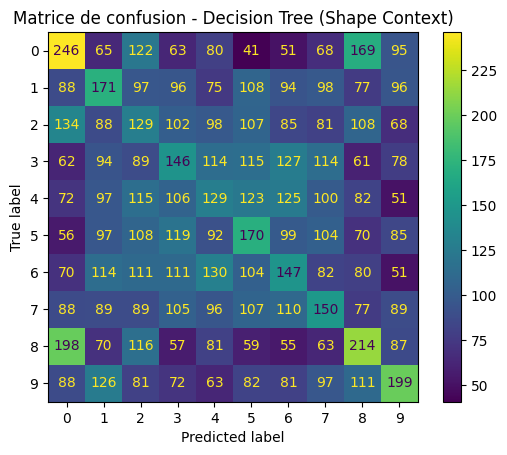

In [31]:
# Matrice de confusion pour Decision Tree (shape context)
cm_dt_shape = confusion_matrix(y_test, y_pred_dt_shape)
disp_dt_shape = ConfusionMatrixDisplay(confusion_matrix=cm_dt_shape)
disp_dt_shape.plot()
plt.title('Matrice de confusion - Decision Tree (Shape Context)')
plt.show()



# --- Matrice de confusion pour la validation croisée ---

# 1. HOG Features (Arbre de décision)

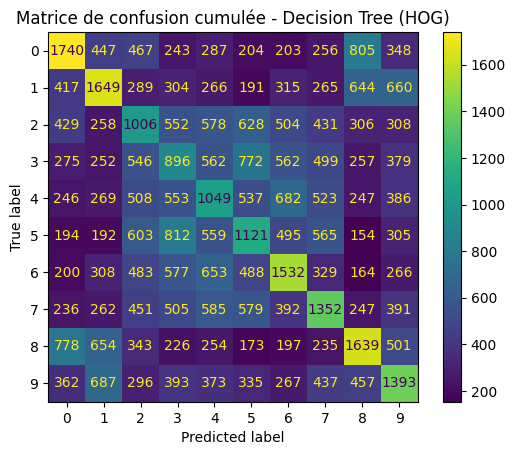

In [32]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Decision Tree (HOG) - prédictions avec validation croisée
y_pred_dt_hog_cv = cross_val_predict(dt_hog_cv, hog_train, y_train, cv=5)
cm_dt_hog_cv = confusion_matrix(y_train, y_pred_dt_hog_cv)
disp_dt_hog_cv = ConfusionMatrixDisplay(confusion_matrix=cm_dt_hog_cv)
disp_dt_hog_cv.plot()
plt.title('Matrice de confusion cumulée - Decision Tree (HOG)')
plt.show()


# 2. HOG Features (Forêts aléatoires)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

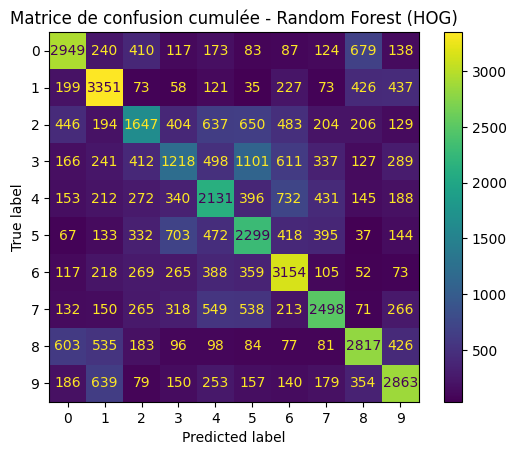

In [33]:
# Random Forest (HOG) - prédictions avec validation croisée
y_pred_rf_hog_cv = cross_val_predict(rf_hog_cv, hog_train, y_train, cv=5)
cm_rf_hog_cv = confusion_matrix(y_train, y_pred_rf_hog_cv)
disp_rf_hog_cv = ConfusionMatrixDisplay(confusion_matrix=cm_rf_hog_cv)
disp_rf_hog_cv.plot()
plt.title('Matrice de confusion cumulée - Random Forest (HOG)')
plt.show()

# 3. Shape Context Features (Arbre de décision)


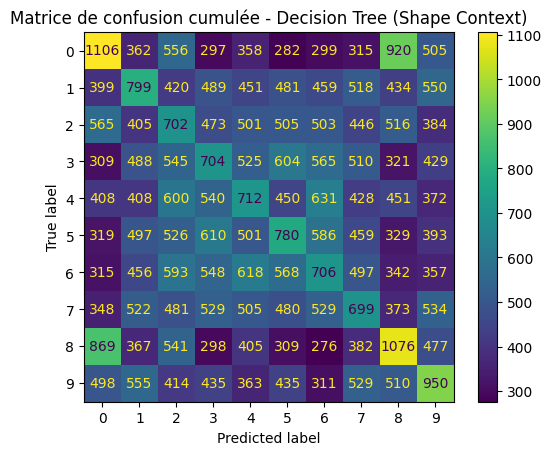

In [34]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Decision Tree (Shape Context) - prédictions avec validation croisée
y_pred_dt_shape_cv = cross_val_predict(dt_shape_cv, shape_context_train, y_train, cv=5)
cm_dt_shape_cv = confusion_matrix(y_train, y_pred_dt_shape_cv)
disp_dt_shape_cv = ConfusionMatrixDisplay(confusion_matrix=cm_dt_shape_cv)
disp_dt_shape_cv.plot()
plt.title('Matrice de confusion cumulée - Decision Tree (Shape Context)')
plt.show()


# 4. Shape Context Features (Forêts aléatoires)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

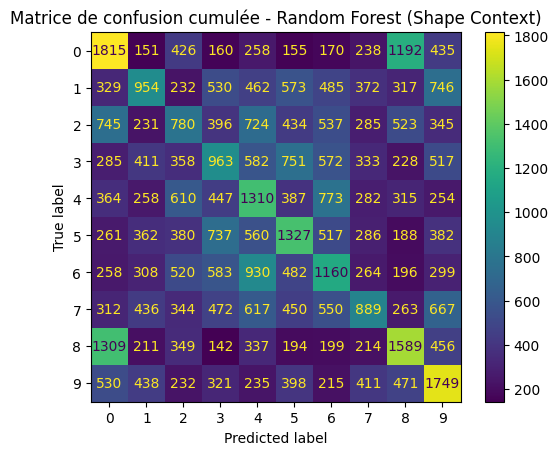

In [35]:

# Random Forest (Shape Context) - prédictions avec validation croisée
y_pred_rf_shape_cv = cross_val_predict(rf_shape_cv, shape_context_train, y_train, cv=5)
cm_rf_shape_cv = confusion_matrix(y_train, y_pred_rf_shape_cv)
disp_rf_shape_cv = ConfusionMatrixDisplay(confusion_matrix=cm_rf_shape_cv)
disp_rf_shape_cv.plot()
plt.title('Matrice de confusion cumulée - Random Forest (Shape Context)')
plt.show()

## Evaluer la performance de l’Arbre de décision et Forêts aléatoires, en utilisant les métriques :
## Rappel, Précision, F-score, et Taux d’erreur.  

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Fonction pour calculer les métriques et construire le DataFrame
def evaluer_modele(y_true, y_pred, nom_modele):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    taux_erreur = 1 - accuracy

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Taux d'erreur": taux_erreur
    }

    return pd.DataFrame([metrics], index=[nom_modele])

# Évaluer les modèles et construire le DataFrame
resultats = pd.concat([
    # --- Évaluations sur le jeu de test ---
    evaluer_modele(y_test, y_pred_dt_hog, "Arbre de décision (HOG, traditionnel)"),
    evaluer_modele(y_test, y_pred_rf_hog, "Forêts aléatoires (HOG, traditionnel)"),
    evaluer_modele(y_test, y_pred_dt_shape, "Arbre de décision (Shape Context, traditionnel)"),
    evaluer_modele(y_test, y_pred_rf_shape, "Forêts aléatoires (Shape Context, traditionnel)"),

    # --- Évaluations pour la validation croisée (sur l'ensemble d'entraînement) ---
    evaluer_modele(y_train, y_pred_dt_hog_cv, "Arbre de décision (HOG, validation croisée)"),
    evaluer_modele(y_train, y_pred_rf_hog_cv, "Forêts aléatoires (HOG, validation croisée)"),
    evaluer_modele(y_train, y_pred_dt_shape_cv, "Arbre de décision (Shape Context, validation croisée)"),
    evaluer_modele(y_train, y_pred_rf_shape_cv, "Forêts aléatoires (Shape Context, validation croisée)")
])


In [39]:
resultats

,Accuracy,Precision,Recall,F1-score,Taux d'erreur
"Arbre de décision (HOG, traditionnel)",0.27630,0.276944,0.27630,0.276469,0.72370
"Forêts aléatoires (HOG, traditionnel)",0.50810,0.505969,0.50810,0.503972,0.49190
"Arbre de décision (Shape Context, traditionnel)",0.17010,0.169885,0.17010,0.169837,0.82990
"Forêts aléatoires (Shape Context, traditionnel)",0.25720,0.254994,0.25720,0.253906,0.74280
"Arbre de décision (HOG, validation croisée)",0.26754,0.268180,0.26754,0.267835,0.73246
"Forêts aléatoires (HOG, validation croisée)",0.49854,0.493701,0.49854,0.493457,0.50146
"Arbre de décision (Shape Context, validation croisée)",0.16468,0.164409,0.16468,0.164491,0.83532
"Forêts aléatoires (Shape Context, validation croisée)",0.25072,0.248112,0.25072,0.247430,0.74928
